# Capstone Project — Adult Census Income Classification

> **Problem:** Predict whether a person earns **>$50K/year** based on census data  
> **Dataset:** UCI Adult Census Income — 32,561 records, 14 features  
> **Type:** Binary Classification  
> **Techniques:** EDA · Feature Engineering · All ML Algorithms · K-Fold CV · GridSearchCV · RandomizedSearchCV · Full Model Evaluation

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Data Loading & Initial Exploration](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Cleaning & Feature Engineering](#4)
5. [Preprocessing Pipeline](#5)
6. [Baseline Models — All Algorithms](#6)
7. [K-Fold Cross Validation](#7)
8. [Hyperparameter Tuning — GridSearchCV](#8)
9. [Hyperparameter Tuning — RandomizedSearchCV](#9)
10. [Final Model Training](#10)
11. [Comprehensive Model Evaluation](#11)
12. [Feature Importance Analysis](#12)
13. [Capstone Summary](#13)

---
<a id='1'></a>
## 1. Setup & Imports

In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute          import SimpleImputer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    cross_validate, GridSearchCV, RandomizedSearchCV, learning_curve
)

# ── Algorithms ────────────────────────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (
    RandomForestClassifier, BaggingClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm           import SVC
import xgboost as xgb

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, average_precision_score, f1_score
)

# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')
SEED = 42

print('All libraries loaded.')
print(f'XGBoost: {xgb.__version__}')

All libraries loaded.
XGBoost: 3.2.0


---
<a id='2'></a>
## 2. Data Loading & Initial Exploration

In [2]:
df = pd.read_csv('adult.csv')

print(f'Shape         : {df.shape}')
print(f'Rows          : {df.shape[0]:,}')
print(f'Features      : {df.shape[1]-1}')
print(f'Target        : income')
df.head()

Shape         : (32561, 15)
Rows          : 32,561
Features      : 14
Target        : income


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing values (stored as "?") ===')
missing = (df == '?').sum()
print(missing[missing > 0])
print('\n=== Target Distribution ===')
print(df['income'].value_counts())
print(f'\nClass imbalance ratio: {df["income"].value_counts(normalize=True).round(3).to_dict()}')

=== Data Types ===
age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

=== Missing values (stored as "?") ===
workclass         1836
occupation        1843
native.country     583
dtype: int64

=== Target Distribution ===
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Class imbalance ratio: {'<=50K': 0.759, '>50K': 0.241}


In [4]:
print('=== Numerical Features — Statistics ===')
df.describe().round(2)

=== Numerical Features — Statistics ===


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [5]:
print('=== Categorical Features — Unique Values ===')
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    vals = [v for v in df[col].unique() if v != '?']
    print(f'  {col:<20}: {len(vals)} unique → {vals[:5]}...' if len(vals)>5 else f'  {col:<20}: {vals}')

=== Categorical Features — Unique Values ===
  workclass           : 8 unique → ['Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc', 'Self-emp-inc']...
  education           : 16 unique → ['HS-grad', 'Some-college', '7th-8th', '10th', 'Doctorate']...
  marital.status      : 7 unique → ['Widowed', 'Divorced', 'Separated', 'Never-married', 'Married-civ-spouse']...
  occupation          : 14 unique → ['Exec-managerial', 'Machine-op-inspct', 'Prof-specialty', 'Other-service', 'Adm-clerical']...
  relationship        : 6 unique → ['Not-in-family', 'Unmarried', 'Own-child', 'Other-relative', 'Husband']...
  race                : ['White', 'Black', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo']
  sex                 : ['Female', 'Male']
  native.country      : 41 unique → ['United-States', 'Mexico', 'Greece', 'Vietnam', 'China']...
  income              : ['<=50K', '>50K']


---
<a id='3'></a>
## 3. Exploratory Data Analysis (EDA)

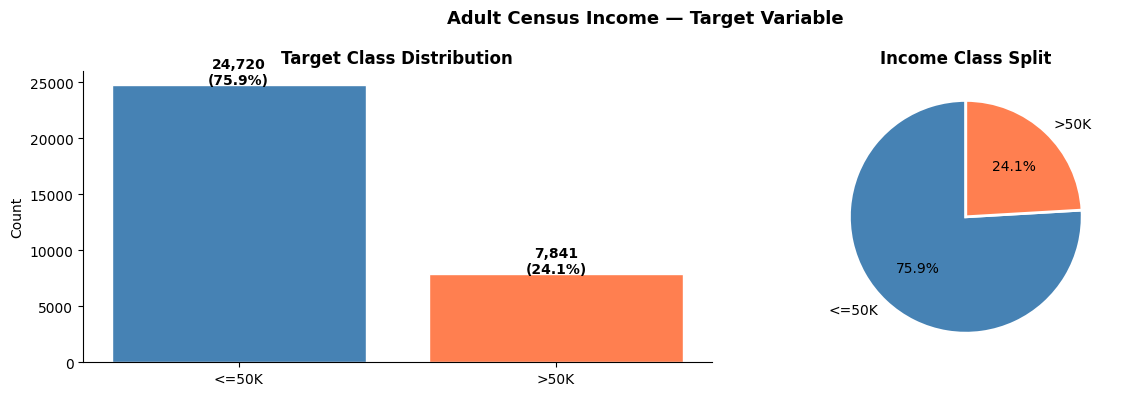

Note: Dataset is imbalanced — ~76% earn <=50K, ~24% earn >50K


In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['income'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=['steelblue','coral'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

pcts = df['income'].value_counts(normalize=True)*100
axes[1].pie(pcts.values, labels=pcts.index, autopct='%1.1f%%',
            colors=['steelblue','coral'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Income Class Split', fontweight='bold')

plt.suptitle('Adult Census Income — Target Variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Note: Dataset is imbalanced — ~76% earn <=50K, ~24% earn >50K')

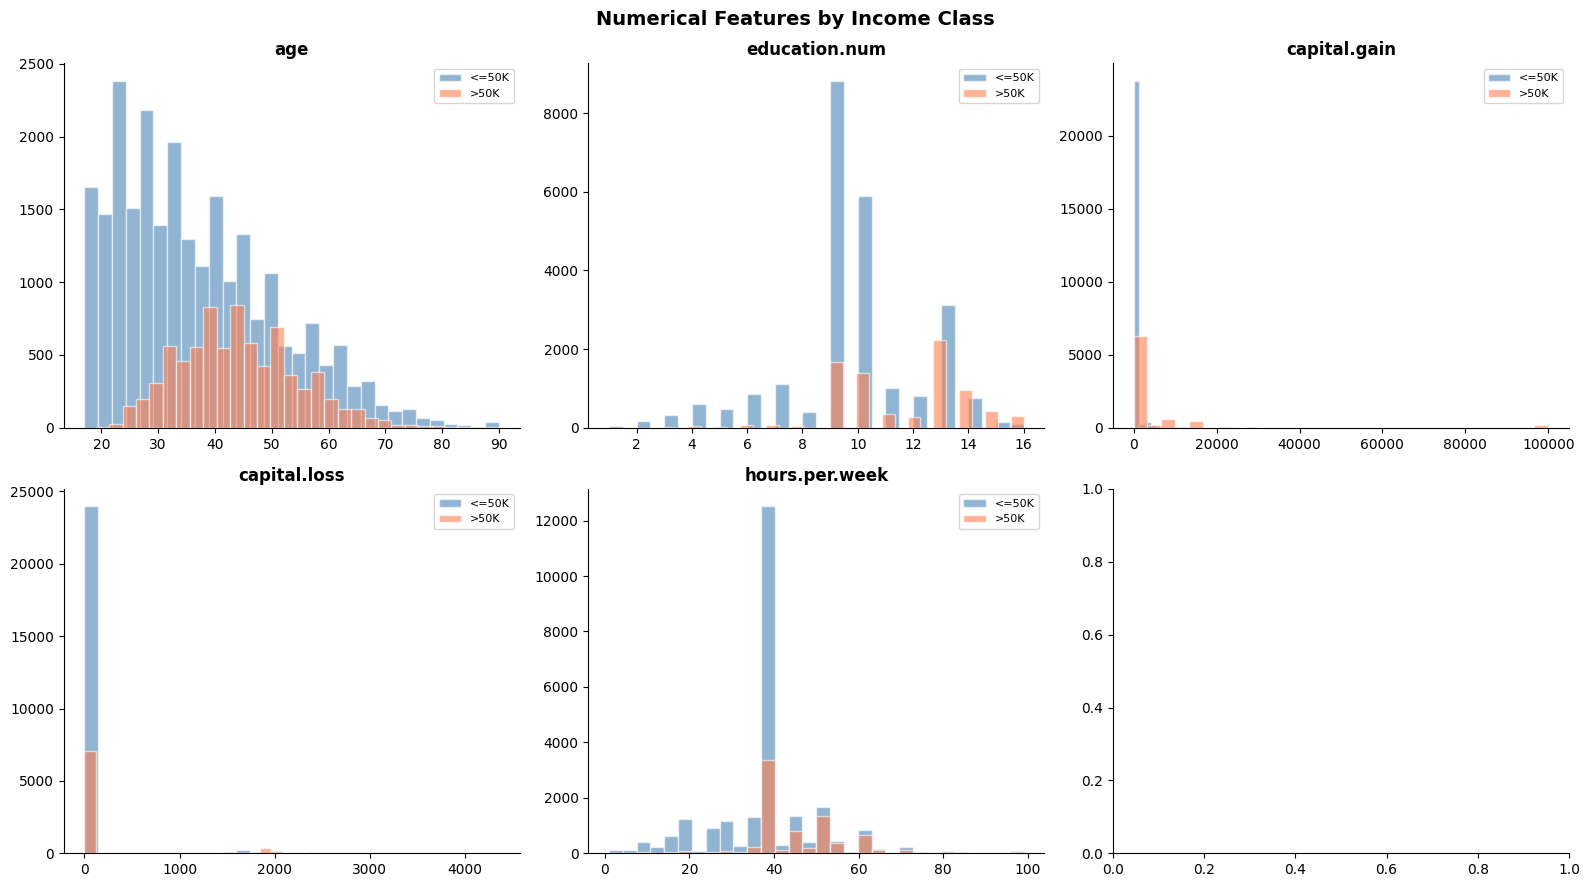

In [7]:
# Numerical feature distributions split by income
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('fnlwgt')  # sampling weight — not a predictive feature

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for income, color in [('<=50K','steelblue'), ('>50K','coral')]:
        axes[i].hist(df[df['income']==income][col], bins=30,
                     alpha=0.6, label=income, color=color, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Features by Income Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

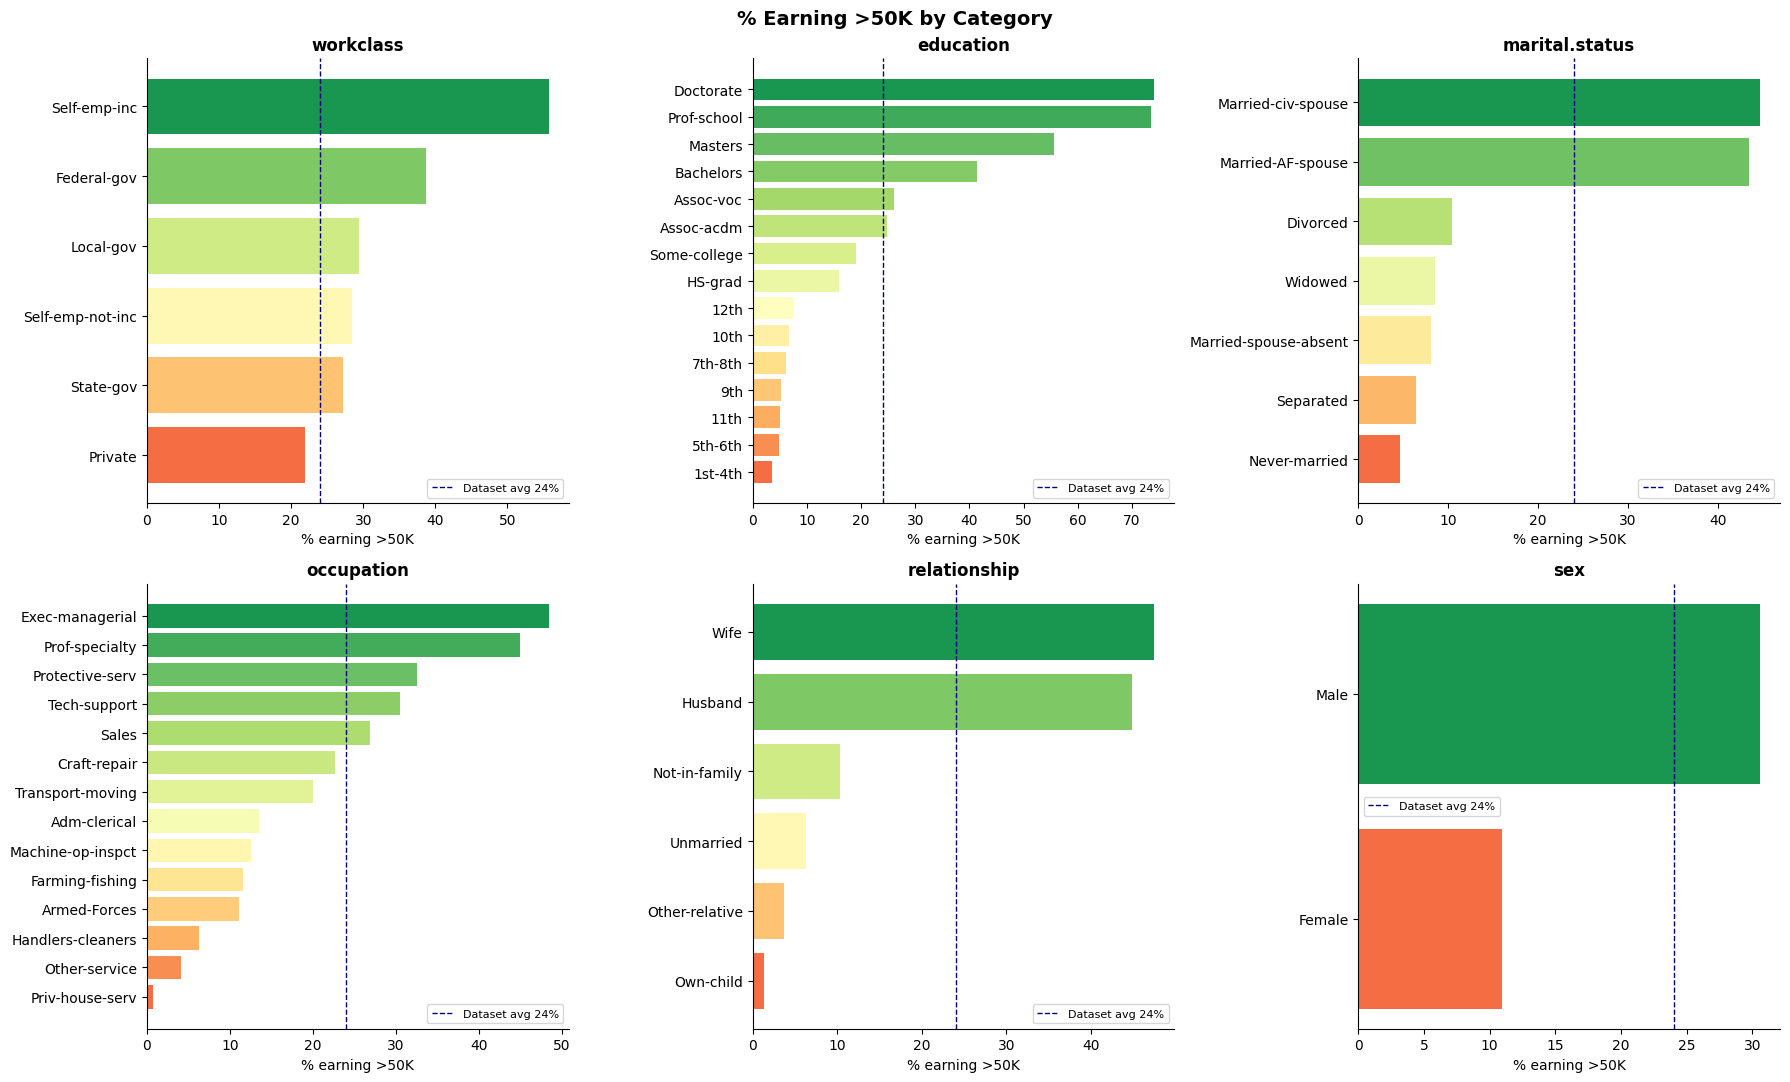

In [8]:
# Categorical features vs income (% earning >50K)
cat_plot_cols = ['workclass','education','marital.status','occupation','relationship','sex']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    pct = (df[df['income']=='>50K'][col].value_counts() /
           df[col].value_counts() * 100).dropna().sort_values(ascending=True)
    pct = pct[pct.index != '?']
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(pct)))
    axes[i].barh(pct.index, pct.values, color=colors)
    axes[i].axvline(24, color='navy', ls='--', lw=1, label='Dataset avg 24%')
    axes[i].set_xlabel('% earning >50K')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('% Earning >50K by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

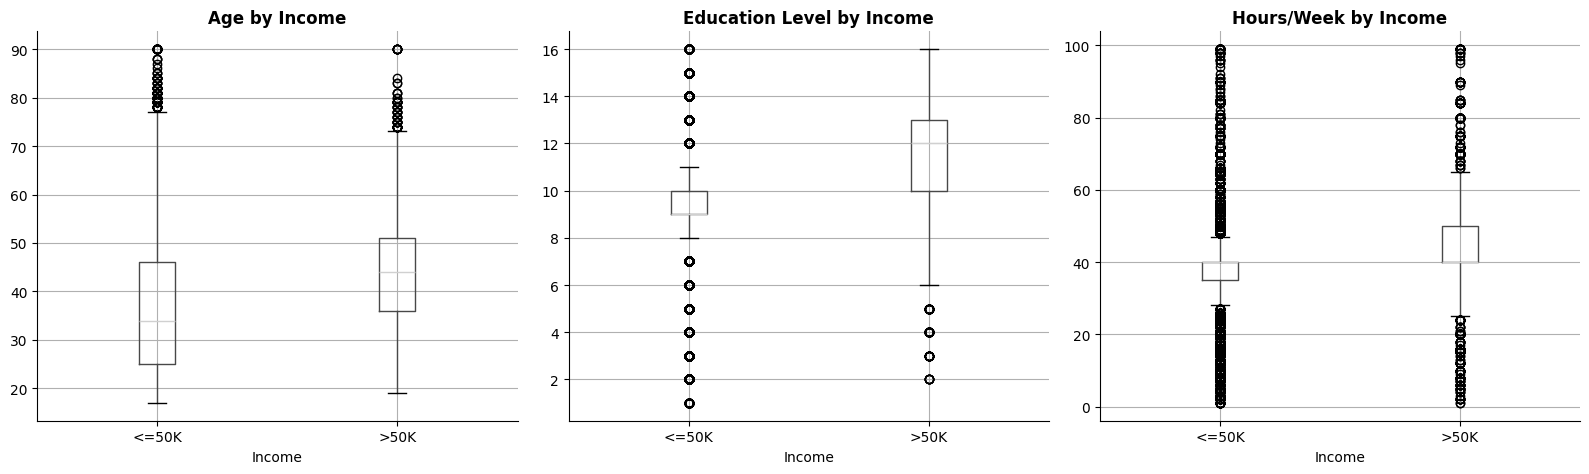

In [9]:
# Age & education-num box plots by income
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df.boxplot(column='age', by='income', ax=axes[0])
axes[0].set_title('Age by Income', fontweight='bold'); axes[0].set_xlabel('Income')

df.boxplot(column='education.num', by='income', ax=axes[1])
axes[1].set_title('Education Level by Income', fontweight='bold'); axes[1].set_xlabel('Income')

df.boxplot(column='hours.per.week', by='income', ax=axes[2])
axes[2].set_title('Hours/Week by Income', fontweight='bold'); axes[2].set_xlabel('Income')

plt.suptitle('')
plt.tight_layout()
plt.show()

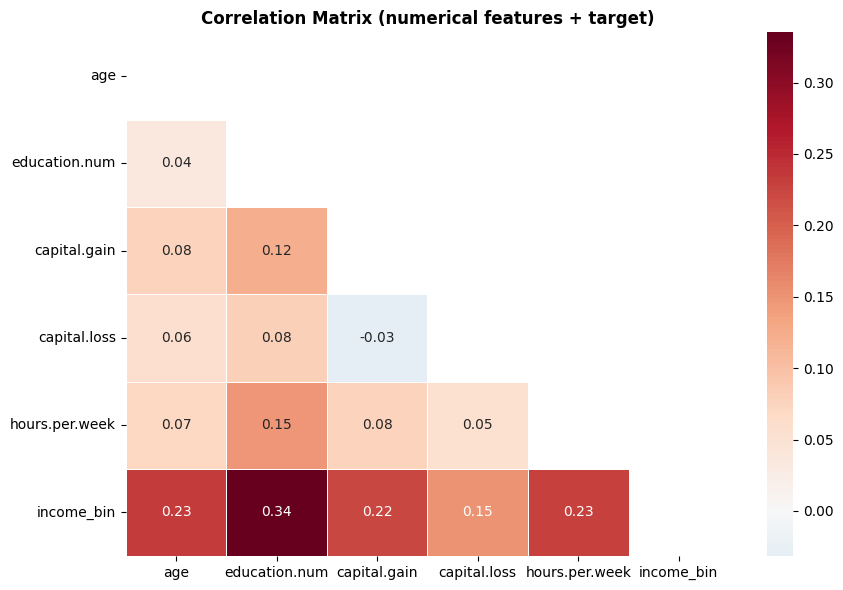

In [10]:
# Correlation heatmap — numerical features
fig, ax = plt.subplots(figsize=(9, 6))
temp = df.copy()
temp['income_bin'] = (temp['income'] == '>50K').astype(int)
num_corr = temp[num_cols + ['income_bin']].corr()
mask = np.triu(np.ones_like(num_corr, dtype=bool))
sns.heatmap(num_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (numerical features + target)', fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='4'></a>
## 4. Data Cleaning & Feature Engineering

In [11]:
df_clean = df.copy()

# ── 1. Replace '?' with NaN ───────────────────────────────────────────────────
df_clean.replace('?', np.nan, inplace=True)

# ── 2. Drop low-value / leaky features ───────────────────────────────────────
df_clean.drop(columns=['fnlwgt', 'education'], inplace=True)
# education.num is the ordinal encoding of education — keep it, drop the text version

# ── 3. Feature Engineering ────────────────────────────────────────────────────
df_clean['capital_net']       = df_clean['capital.gain'] - df_clean['capital.loss']
df_clean['has_capital']       = (df_clean['capital_net'] != 0).astype(int)
df_clean['overtime']          = (df_clean['hours.per.week'] > 40).astype(int)
df_clean['is_married']        = df_clean['marital.status'].isin(
    ['Married-civ-spouse', 'Married-AF-spouse']).astype(int)

# Bin age into groups
df_clean['age_group'] = pd.cut(df_clean['age'],
    bins=[0,25,35,45,55,100], labels=['<25','25-35','35-45','45-55','55+'])

# ── 4. Encode target ──────────────────────────────────────────────────────────
df_clean['income'] = (df_clean['income'].str.strip() == '>50K').astype(int)

print(f'Shape after cleaning: {df_clean.shape}')
print(f'Missing values remaining:\n{df_clean.isnull().sum()[df_clean.isnull().sum()>0]}')
print(f'\nTarget: 0=<=50K ({(df_clean.income==0).sum():,})  1=>50K ({(df_clean.income==1).sum():,})')

Shape after cleaning: (32561, 18)
Missing values remaining:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Target: 0=<=50K (24,720)  1=>50K (7,841)


In [12]:
# ── Define feature groups ─────────────────────────────────────────────────────
TARGET = 'income'

NUM_FEATURES = [
    'age', 'education.num', 'capital.gain', 'capital.loss',
    'hours.per.week', 'capital_net'
]
CAT_FEATURES = [
    'workclass', 'marital.status', 'occupation',
    'relationship', 'race', 'sex', 'native.country', 'age_group'
]
BIN_FEATURES = ['has_capital', 'overtime', 'is_married']

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES + BIN_FEATURES

X = df_clean[ALL_FEATURES]
y = df_clean[TARGET]

# ── Stratified Train / Test Split ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train target: {y_train.value_counts().to_dict()}')
print(f'Test  target: {y_test.value_counts().to_dict()}')

Train: (26048, 17)  |  Test: (6513, 17)
Train target: {0: 19775, 1: 6273}
Test  target: {0: 4945, 1: 1568}


---
<a id='5'></a>
## 5. Preprocessing Pipeline

Using `sklearn.Pipeline` and `ColumnTransformer` — fits on train only, transforms both train and test to prevent **data leakage**.

In [13]:
from sklearn.preprocessing import OneHotEncoder

# ── Numerical: impute median → scale ─────────────────────────────────────────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ── Categorical: impute mode → one-hot encode ─────────────────────────────────
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── Binary: pass through as-is ───────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_FEATURES),
    ('cat', cat_pipe, CAT_FEATURES),
    ('bin', 'passthrough', BIN_FEATURES)
])

# Fit on train, transform both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Processed feature count: {X_train_proc.shape[1]}')
print(f'Train shape: {X_train_proc.shape}')
print(f'Test  shape: {X_test_proc.shape}')

Processed feature count: 96
Train shape: (26048, 96)
Test  shape: (6513, 96)


---
<a id='6'></a>
## 6. Baseline Models — All Algorithms

Train every algorithm with **default hyperparameters** to establish baseline performance before tuning.

In [14]:
BASELINE_MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEED),
    'KNN'                 : KNeighborsClassifier(n_neighbors=11),
    'Decision Tree'       : DecisionTreeClassifier(random_state=SEED),
    'Bagging'             : BaggingClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'SVM'                 : SVC(probability=True, random_state=SEED),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=100, random_state=SEED,
                                              n_jobs=-1, verbosity=0, tree_method='hist'),
}

baseline_results = {}

print(f'{"Model":<22} {"Accuracy":>10} {"ROC-AUC":>10} {"F1":>10}')
print('-' * 54)

for name, model in BASELINE_MODELS.items():
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_test_proc)
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    baseline_results[name] = {'Accuracy': acc, 'ROC-AUC': auc, 'F1': f1}
    print(f'{name:<22} {acc:>10.4f} {auc:>10.4f} {f1:>10.4f}')

print('-' * 54)

Model                    Accuracy    ROC-AUC         F1
------------------------------------------------------


Logistic Regression        0.8555     0.9069     0.6718


KNN                        0.8469     0.8901     0.6601


Decision Tree              0.8159     0.7565     0.6070


Bagging                    0.8472     0.8904     0.6596


Random Forest              0.8471     0.8901     0.6575


SVM                        0.8560     0.8929     0.6628


AdaBoost                   0.8489     0.9026     0.6440


Gradient Boosting          0.8597     0.9146     0.6712


XGBoost                    0.8700     0.9229     0.7072
------------------------------------------------------


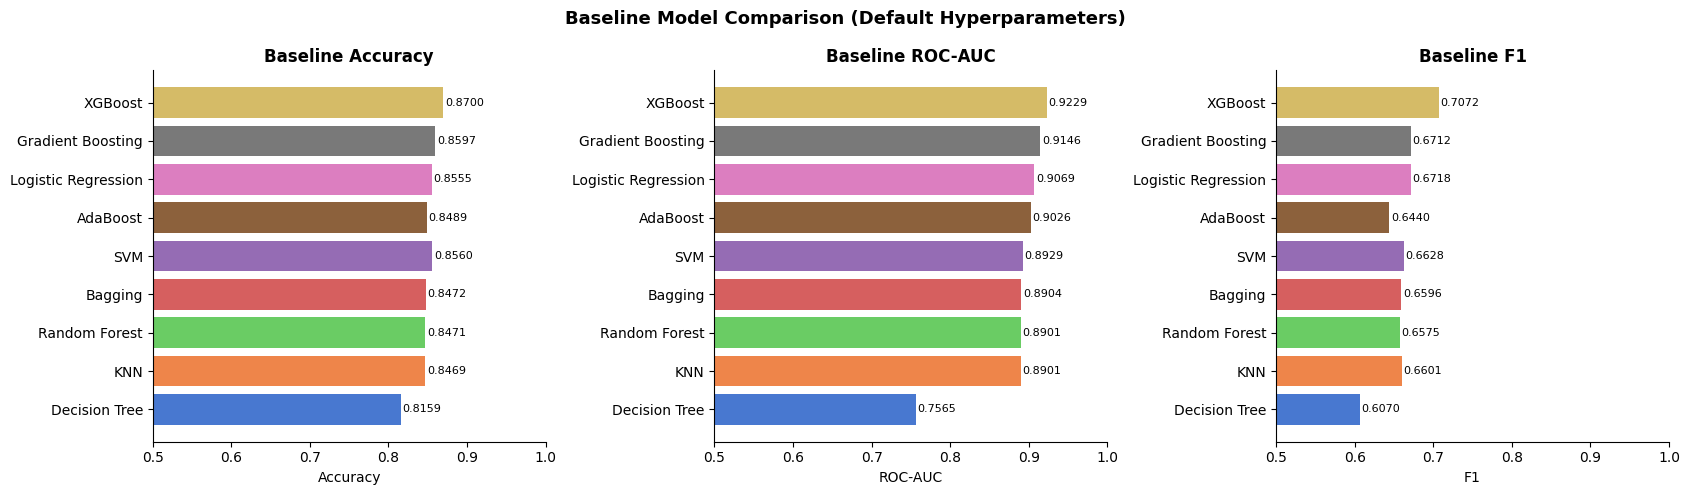

In [15]:
# Baseline comparison chart
bl_df = pd.DataFrame(baseline_results).T.sort_values('ROC-AUC', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
palette = sns.color_palette('muted', len(bl_df))

for ax, metric in zip(axes, ['Accuracy', 'ROC-AUC', 'F1']):
    bars = ax.barh(bl_df.index, bl_df[metric], color=palette)
    ax.set_xlabel(metric)
    ax.set_title(f'Baseline {metric}', fontweight='bold')
    ax.set_xlim(0.5, 1.0)
    for bar, val in zip(bars, bl_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Baseline Model Comparison (Default Hyperparameters)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='7'></a>
## 7. K-Fold Cross Validation

**Stratified K-Fold** preserves the class ratio in each fold — essential for imbalanced datasets.

```
Full Training Data
┌────┬────┬────┬────┬────┐
│ F1 │ F2 │ F3 │ F4 │ F5 │
└────┴────┴────┴────┴────┘

Fold 1: Train=[F2,F3,F4,F5]  Val=[F1]
Fold 2: Train=[F1,F3,F4,F5]  Val=[F2]
...                              ...  ← each fold gets its turn as validation
Fold 5: Train=[F1,F2,F3,F4]  Val=[F5]

Final score = mean of 5 fold scores
```

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

CV_MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=8, random_state=SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=100, random_state=SEED,
                                              n_jobs=-1, verbosity=0, tree_method='hist'),
}

cv_results = {}
print('5-Fold Stratified Cross-Validation Results')
print(f'{"Model":<22} {"Mean AUC":>10} {"Std AUC":>10} {"Mean Acc":>10} {"Std Acc":>10}')
print('-'*64)

for name, model in CV_MODELS.items():
    cv_out = cross_validate(
        model, X_train_proc, y_train,
        cv=skf,
        scoring={'auc': 'roc_auc', 'acc': 'accuracy'},
        n_jobs=-1
    )
    cv_results[name] = {
        'Mean AUC': cv_out['test_auc'].mean(),
        'Std AUC' : cv_out['test_auc'].std(),
        'Mean Acc': cv_out['test_acc'].mean(),
        'Std Acc' : cv_out['test_acc'].std(),
        'Fold AUCs': cv_out['test_auc']
    }
    print(f'{name:<22} {cv_out["test_auc"].mean():>10.4f} '
          f'{cv_out["test_auc"].std():>10.4f} '
          f'{cv_out["test_acc"].mean():>10.4f} '
          f'{cv_out["test_acc"].std():>10.4f}')

print('-'*64)

5-Fold Stratified Cross-Validation Results
Model                    Mean AUC    Std AUC   Mean Acc    Std Acc
----------------------------------------------------------------


Logistic Regression        0.9127     0.0018     0.8585     0.0030


Decision Tree              0.9000     0.0027     0.8554     0.0042


Random Forest              0.8961     0.0012     0.8495     0.0018


AdaBoost                   0.9099     0.0010     0.8556     0.0028


Gradient Boosting          0.9221     0.0018     0.8664     0.0029


XGBoost                    0.9276     0.0017     0.8714     0.0025
----------------------------------------------------------------


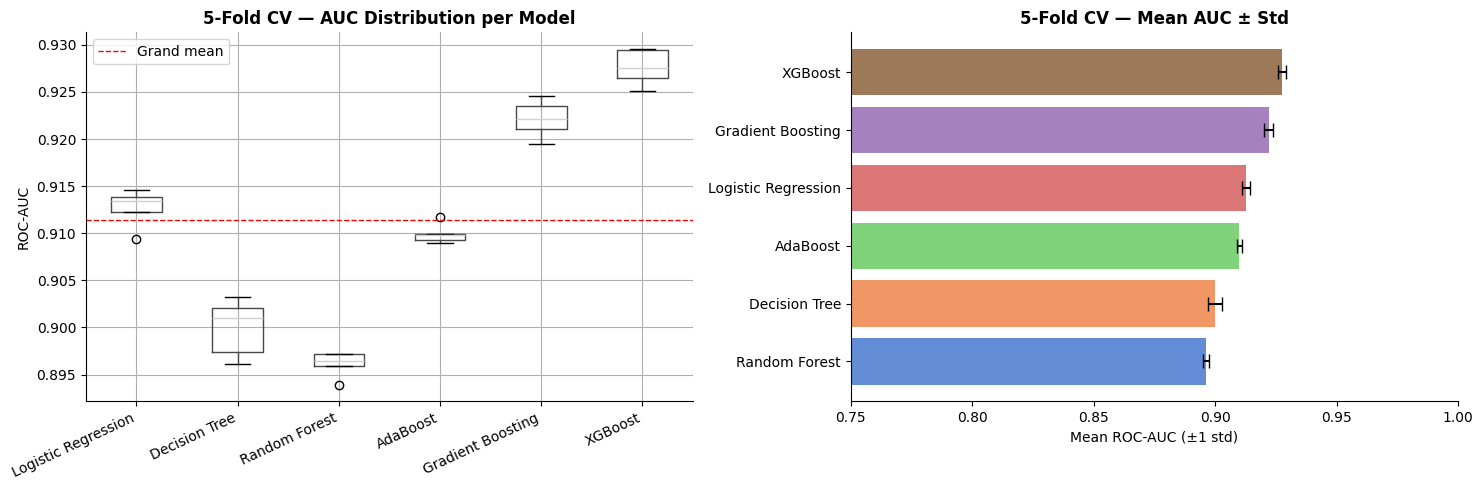

In [17]:
# CV results — box plot per model (shows variance across folds)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fold_aucs = pd.DataFrame({n: v['Fold AUCs'] for n,v in cv_results.items()})
fold_aucs.boxplot(ax=axes[0])
axes[0].set_xticklabels(fold_aucs.columns, rotation=25, ha='right')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('5-Fold CV — AUC Distribution per Model', fontweight='bold')
axes[0].axhline(fold_aucs.values.mean(), color='red', ls='--', lw=1, label='Grand mean')
axes[0].legend()

# Mean AUC ± std
cv_df = pd.DataFrame({k: {'Mean': v['Mean AUC'], 'Std': v['Std AUC']}
                      for k,v in cv_results.items()}).T.sort_values('Mean', ascending=True)
axes[1].barh(cv_df.index, cv_df['Mean'], xerr=cv_df['Std'],
             capsize=5, color=sns.color_palette('muted',len(cv_df)), alpha=0.85)
axes[1].set_xlabel('Mean ROC-AUC (±1 std)')
axes[1].set_title('5-Fold CV — Mean AUC ± Std', fontweight='bold')
axes[1].set_xlim(0.75, 1.0)

plt.tight_layout()
plt.show()

---
<a id='8'></a>
## 8. Hyperparameter Tuning — GridSearchCV

**GridSearchCV** exhaustively tests every combination of parameters. Use when the search space is small.

We tune the **top 3 models** from CV: Random Forest, Gradient Boosting, Logistic Regression.

In [18]:
# ── GridSearch: Logistic Regression ──────────────────────────────────────────
lr_param_grid = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEED),
    lr_param_grid,
    cv=skf, scoring='roc_auc', n_jobs=-1, verbose=0
)
gs_lr.fit(X_train_proc, y_train)

print('=== GridSearchCV — Logistic Regression ===')
print(f'Best params : {gs_lr.best_params_}')
print(f'Best CV AUC : {gs_lr.best_score_:.4f}')

=== GridSearchCV — Logistic Regression ===
Best params : {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC : 0.9128


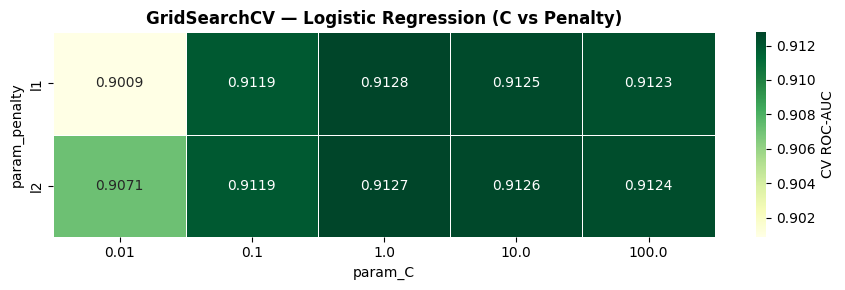

In [19]:
# Visualise LR grid — C vs penalty heatmap
lr_res = pd.DataFrame(gs_lr.cv_results_)
heatmap_data = lr_res.pivot_table(
    values='mean_test_score',
    index='param_penalty',
    columns='param_C'
)
plt.figure(figsize=(9, 3))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'CV ROC-AUC'})
plt.title('GridSearchCV — Logistic Regression (C vs Penalty)', fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ── GridSearch: Random Forest ─────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 10, 20],
    'min_samples_leaf': [1, 3, 5],
    'max_features'    : ['sqrt', 'log2']
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_param_grid,
    cv=skf, scoring='roc_auc', n_jobs=-1, verbose=1
)
gs_rf.fit(X_train_proc, y_train)

print('\n=== GridSearchCV — Random Forest ===')
print(f'Best params : {gs_rf.best_params_}')
print(f'Best CV AUC : {gs_rf.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits



=== GridSearchCV — Random Forest ===
Best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV AUC : 0.9187


In [21]:
# ── GridSearch: Gradient Boosting (compact grid — sequential training is slow) ─
gb_param_grid = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1],
    'max_depth'     : [3, 4],
    'subsample'     : [0.8]
}
# 2×2×2×1 = 8 combos × 5 folds = 40 fits

gs_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    gb_param_grid,
    cv=skf, scoring='roc_auc', n_jobs=-1, verbose=1
)
gs_gb.fit(X_train_proc, y_train)

print('\n=== GridSearchCV — Gradient Boosting ===')
print(f'Best params : {gs_gb.best_params_}')
print(f'Best CV AUC : {gs_gb.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits



=== GridSearchCV — Gradient Boosting ===
Best params : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC : 0.9274


In [22]:
# GridSearch summary
print('=== GridSearchCV Summary ===')
print(f'{"Model":<22} {"Best CV AUC":>12}  Best Params')
print('-'*80)
for name, gs in [("Logistic Reg", gs_lr), ("Random Forest", gs_rf), ("Gradient Boost", gs_gb)]:
    print(f'{name:<22} {gs.best_score_:>12.4f}  {gs.best_params_}')

=== GridSearchCV Summary ===
Model                   Best CV AUC  Best Params
--------------------------------------------------------------------------------
Logistic Reg                 0.9128  {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Random Forest                0.9187  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}
Gradient Boost               0.9274  {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


---
<a id='9'></a>
## 9. Hyperparameter Tuning — RandomizedSearchCV

**RandomizedSearchCV** samples parameter combinations randomly — efficient for large search spaces. Ideal for XGBoost with many parameters.

```
GridSearchCV     : tests ALL combinations → slow but exhaustive
RandomizedSearchCV: tests N random samples → fast, covers wide range
```

In [23]:
from scipy.stats import uniform, randint

xgb_param_dist = {
    'n_estimators'      : randint(100, 400),
    'learning_rate'     : uniform(0.01, 0.25),
    'max_depth'         : randint(3, 8),
    'subsample'         : uniform(0.6, 0.4),
    'colsample_bytree'  : uniform(0.6, 0.4),
    'reg_alpha'         : uniform(0, 1.5),
    'reg_lambda'        : uniform(0.5, 3),
    'min_child_weight'  : randint(1, 8),
    'gamma'             : uniform(0, 0.5)
}

rs_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=SEED, n_jobs=-1, verbosity=0, tree_method='hist'),
    param_distributions=xgb_param_dist,
    n_iter=25,           # 25 random combos × 3 folds = 75 fits
    cv=3,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
rs_xgb.fit(X_train_proc, y_train)

print(f'\nBest CV AUC : {rs_xgb.best_score_:.4f}')
print(f'Best params :')
for k, v in rs_xgb.best_params_.items():
    print(f'  {k:<22}: {round(v,4) if isinstance(v,float) else v}')

Fitting 3 folds for each of 25 candidates, totalling 75 fits



Best CV AUC : 0.9287
Best params :
  colsample_bytree      : 0.6968
  gamma                 : 0.3361
  learning_rate         : 0.2004
  max_depth             : 5
  min_child_weight      : 1
  n_estimators          : 354
  reg_alpha             : 1.2047
  reg_lambda            : 1.9109
  subsample             : 0.9934


In [24]:
# RandomizedSearch for Random Forest — wide search, 3-fold for speed
rf_param_dist = {
    'n_estimators'      : randint(100, 300),
    'max_depth'         : [None, 10, 20, 30],
    'min_samples_split' : randint(2, 15),
    'min_samples_leaf'  : randint(1, 8),
    'max_features'      : ['sqrt', 'log2', 0.4],
    'class_weight'      : [None, 'balanced']
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,   # 20 random combos × 3 folds = 60 fits
    cv=3,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
rs_rf.fit(X_train_proc, y_train)

print(f'\nBest RF CV AUC : {rs_rf.best_score_:.4f}')
print(f'Best RF params : {rs_rf.best_params_}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits



Best RF CV AUC : 0.9198
Best RF params : {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 0.4, 'min_samples_leaf': 1, 'min_samples_split': 12, 'n_estimators': 104}


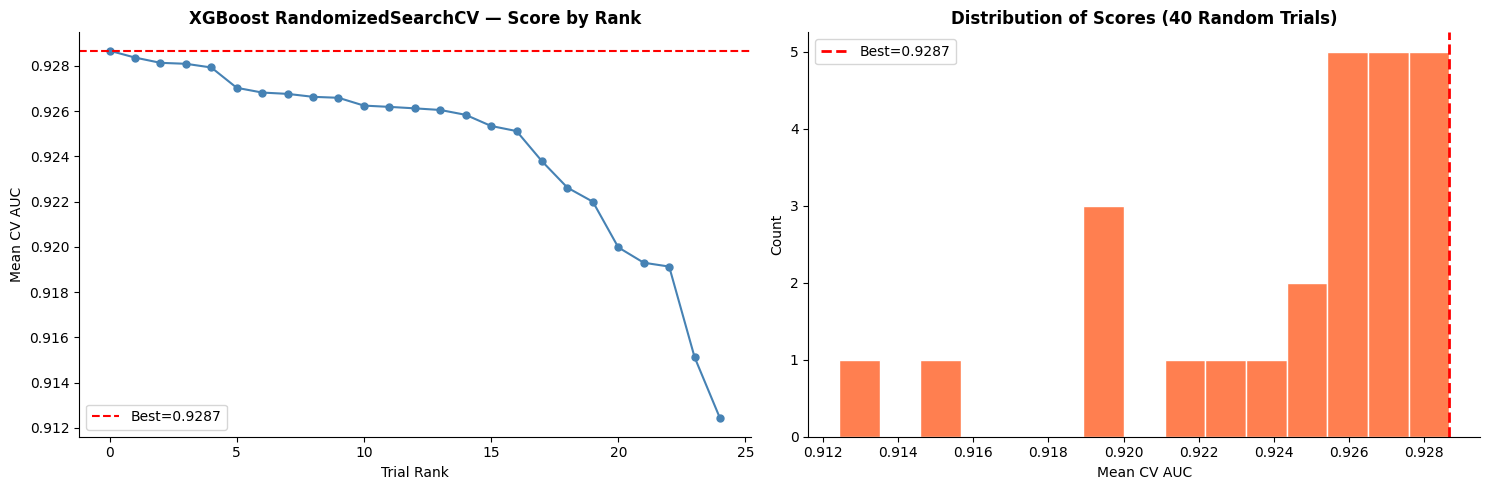

In [25]:
# Plot RandomizedSearch scores — how scores vary across random trials
rs_scores = rs_xgb.cv_results_['mean_test_score']
rs_ranks  = rs_xgb.cv_results_['rank_test_score']
sorted_idx = np.argsort(rs_ranks)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(sorted_scores := rs_scores[sorted_idx], 'o-', color='steelblue', ms=5)
axes[0].axhline(rs_xgb.best_score_, color='red', ls='--', lw=1.5,
                label=f'Best={rs_xgb.best_score_:.4f}')
axes[0].set_xlabel('Trial Rank')
axes[0].set_ylabel('Mean CV AUC')
axes[0].set_title('XGBoost RandomizedSearchCV — Score by Rank', fontweight='bold')
axes[0].legend()

axes[1].hist(rs_scores, bins=15, color='coral', edgecolor='white')
axes[1].axvline(rs_xgb.best_score_, color='red', ls='--', lw=2,
                label=f'Best={rs_xgb.best_score_:.4f}')
axes[1].set_xlabel('Mean CV AUC')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Scores (40 Random Trials)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

---
<a id='10'></a>
## 10. Final Model Training

Train the best version of each model using optimal hyperparameters found above.

In [26]:
FINAL_MODELS = {
    'Logistic Regression (Tuned)': gs_lr.best_estimator_,
    'Random Forest (GridCV)'     : gs_rf.best_estimator_,
    'Random Forest (RandomCV)'   : rs_rf.best_estimator_,
    'Gradient Boosting (GridCV)' : gs_gb.best_estimator_,
    'XGBoost (RandomCV)'         : rs_xgb.best_estimator_,
    # baselines for reference
    'AdaBoost (Default)'         : BASELINE_MODELS['AdaBoost'],
    'Decision Tree (Default)'    : BASELINE_MODELS['Decision Tree'],
}

# All best_estimators are already fitted — just collect predictions
final_results = {}
predictions   = {}
probabilities = {}

print(f'{"Model":<35} {"Accuracy":>10} {"ROC-AUC":>10} {"F1":>10} {"Precision":>10} {"Recall":>10}')
print('-'*87)

for name, model in FINAL_MODELS.items():
    y_pred = model.predict(X_test_proc)
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    predictions[name]   = y_pred
    probabilities[name] = y_prob

    from sklearn.metrics import precision_score, recall_score
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    final_results[name] = {
        'Accuracy':acc, 'ROC-AUC':auc, 'F1':f1, 'Precision':prec, 'Recall':rec
    }
    print(f'{name:<35} {acc:>10.4f} {auc:>10.4f} {f1:>10.4f} {prec:>10.4f} {rec:>10.4f}')

print('-'*87)

Model                                 Accuracy    ROC-AUC         F1  Precision     Recall
---------------------------------------------------------------------------------------
Logistic Regression (Tuned)             0.8557     0.9070     0.6716     0.7427     0.6129
Random Forest (GridCV)                  0.8606     0.9140     0.6674     0.7840     0.5810


Random Forest (RandomCV)                0.8402     0.9133     0.7057     0.6338     0.7959
Gradient Boosting (GridCV)              0.8686     0.9212     0.7022     0.7726     0.6435
XGBoost (RandomCV)                      0.8713     0.9239     0.7106     0.7748     0.6562


AdaBoost (Default)                      0.8489     0.9026     0.6440     0.7441     0.5676
Decision Tree (Default)                 0.8159     0.7565     0.6070     0.6244     0.5906
---------------------------------------------------------------------------------------


---
<a id='11'></a>
## 11. Comprehensive Model Evaluation

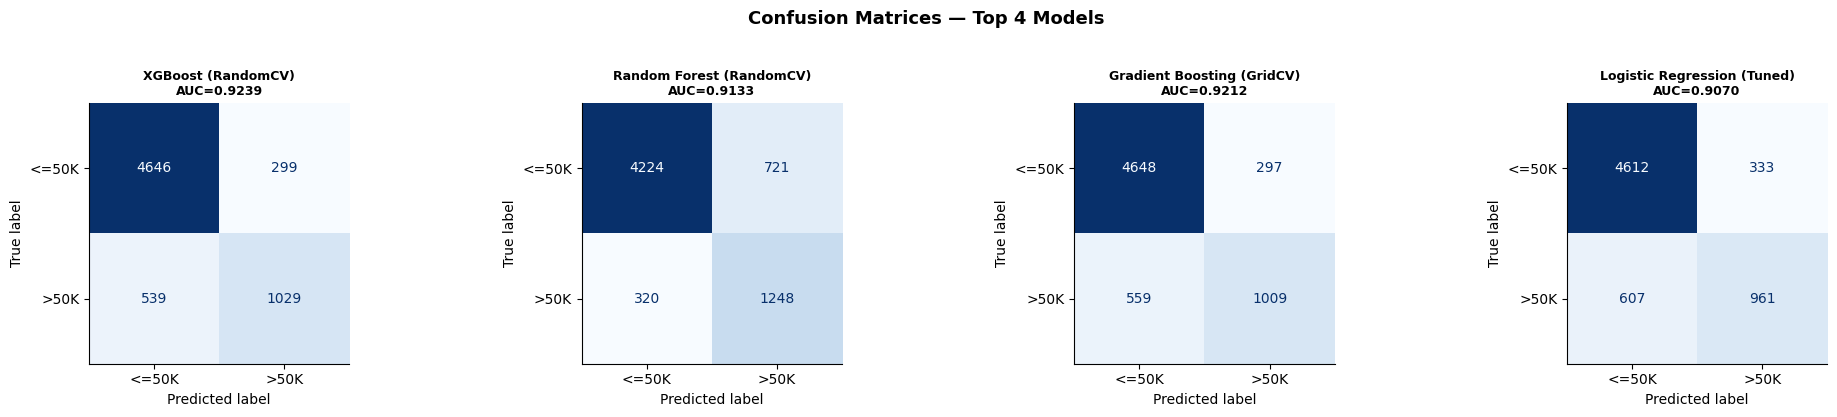

In [27]:
# ── 11A. Confusion Matrices — top 4 models ────────────────────────────────────
top4 = ['XGBoost (RandomCV)', 'Random Forest (RandomCV)',
        'Gradient Boosting (GridCV)', 'Logistic Regression (Tuned)']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, name in zip(axes, top4):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    auc = final_results[name]['ROC-AUC']
    ax.set_title(f'{name}\nAUC={auc:.4f}', fontsize=9, fontweight='bold')

plt.suptitle('Confusion Matrices — Top 4 Models', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [28]:
# ── 11B. Classification Reports ───────────────────────────────────────────────
for name in top4:
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, predictions[name],
                                target_names=['<=50K', '>50K']))


  XGBoost (RandomCV)
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4945
        >50K       0.77      0.66      0.71      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.80      0.81      6513
weighted avg       0.87      0.87      0.87      6513


  Random Forest (RandomCV)
              precision    recall  f1-score   support

       <=50K       0.93      0.85      0.89      4945
        >50K       0.63      0.80      0.71      1568

    accuracy                           0.84      6513
   macro avg       0.78      0.83      0.80      6513
weighted avg       0.86      0.84      0.85      6513


  Gradient Boosting (GridCV)
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      4945
        >50K       0.77      0.64      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.81     

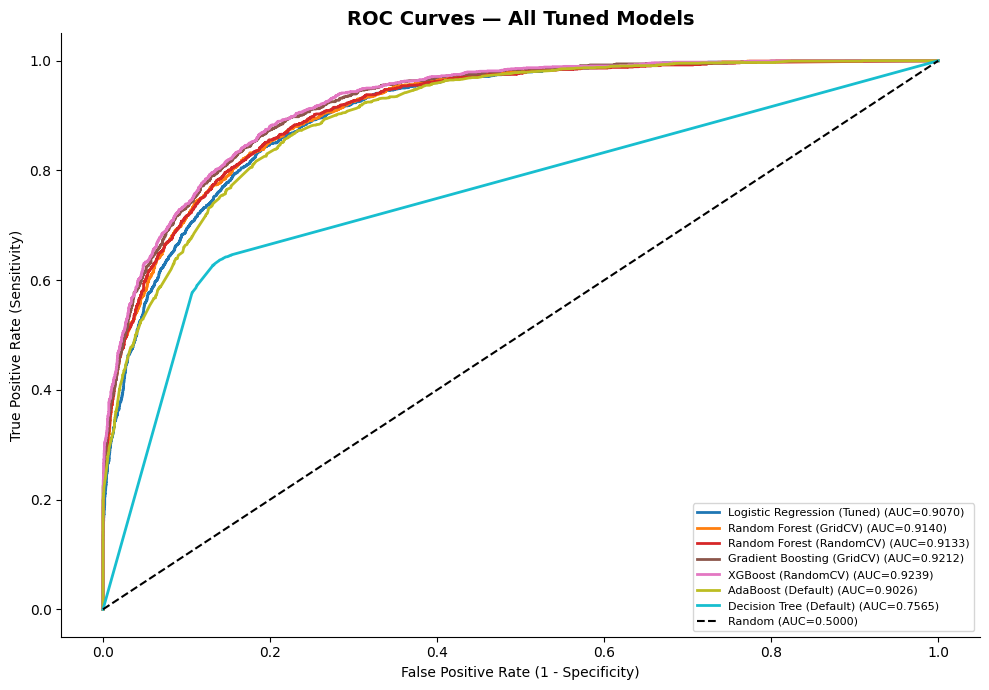

In [29]:
# ── 11C. ROC Curves — all models on one plot ──────────────────────────────────
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(FINAL_MODELS)))

for (name, y_prob), color in zip(probabilities.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Random (AUC=0.5000)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves — All Tuned Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

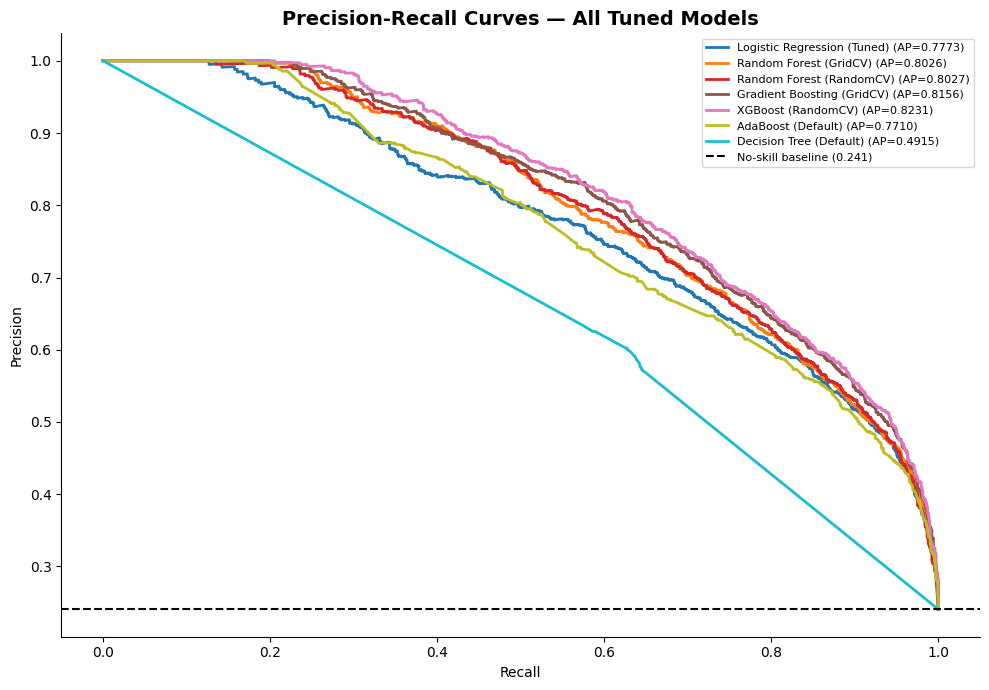

In [30]:
# ── 11D. Precision-Recall Curves ──────────────────────────────────────────────
plt.figure(figsize=(10, 7))
baseline_pr = y_test.mean()

for (name, y_prob), color in zip(probabilities.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(rec, prec, lw=2, color=color, label=f'{name} (AP={ap:.4f})')

plt.axhline(baseline_pr, color='k', ls='--', lw=1.5,
            label=f'No-skill baseline ({baseline_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Tuned Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

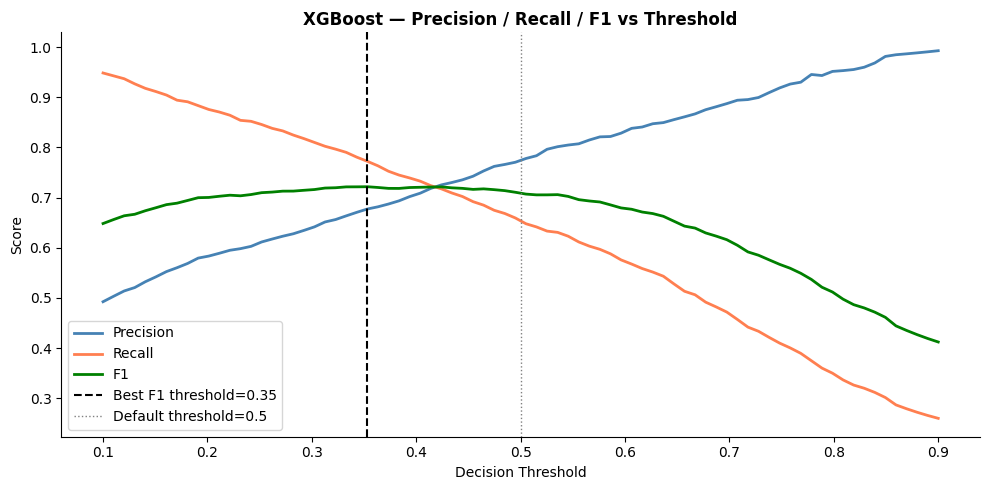

Default threshold (0.50): F1=0.7107
Optimal threshold (0.35): F1=0.7217


In [31]:
# ── 11E. Threshold Analysis — Precision, Recall, F1 vs Threshold ──────────────
# (for the best model: XGBoost)
best_probs = probabilities['XGBoost (RandomCV)']
thresholds = np.linspace(0.1, 0.9, 80)

prec_arr, rec_arr, f1_arr = [], [], []
from sklearn.metrics import precision_score, recall_score
for thr in thresholds:
    preds_thr = (best_probs >= thr).astype(int)
    prec_arr.append(precision_score(y_test, preds_thr, zero_division=0))
    rec_arr.append(recall_score(y_test, preds_thr, zero_division=0))
    f1_arr.append(f1_score(y_test, preds_thr, zero_division=0))

best_thr_idx = np.argmax(f1_arr)
best_thr     = thresholds[best_thr_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, prec_arr, label='Precision', color='steelblue',   lw=2)
plt.plot(thresholds, rec_arr,  label='Recall',    color='coral',       lw=2)
plt.plot(thresholds, f1_arr,   label='F1',        color='green',       lw=2)
plt.axvline(best_thr, color='black', ls='--', lw=1.5,
            label=f'Best F1 threshold={best_thr:.2f}')
plt.axvline(0.5, color='grey', ls=':', lw=1, label='Default threshold=0.5')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('XGBoost — Precision / Recall / F1 vs Threshold', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Default threshold (0.50): F1={f1_arr[np.argmin(abs(thresholds-0.5))]:.4f}')
print(f'Optimal threshold ({best_thr:.2f}): F1={max(f1_arr):.4f}')

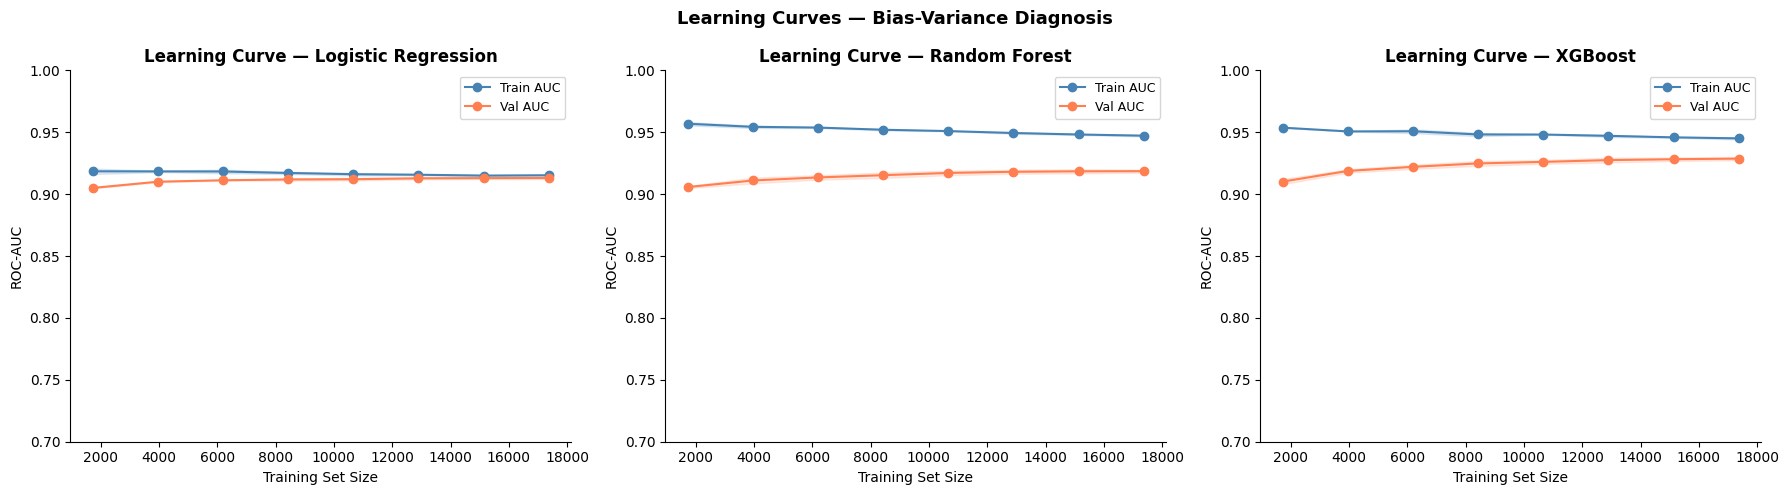

Converging train/val lines → good fit | Large gap → overfitting | Both low → underfitting


In [32]:
# ── 11F. Learning Curves — Bias vs Variance Diagnosis ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lc_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, **{k:v for k,v in gs_lr.best_params_.items()}),
    'Random Forest'      : RandomForestClassifier(**gs_rf.best_params_, random_state=SEED, n_jobs=-1),
    'XGBoost'            : rs_xgb.best_estimator_
}

for ax, (name, model) in zip(axes, lc_models.items()):
    train_sizes, train_sc, val_sc = learning_curve(
        model, X_train_proc, y_train,
        cv=3, scoring='roc_auc', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8)
    )
    tr_mean, tr_std = train_sc.mean(axis=1), train_sc.std(axis=1)
    vl_mean, vl_std = val_sc.mean(axis=1),   val_sc.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Train AUC')
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='steelblue')
    ax.plot(train_sizes, vl_mean, 'o-', color='coral',     label='Val AUC')
    ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=0.15, color='coral')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('ROC-AUC')
    ax.set_title(f'Learning Curve — {name}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0.7, 1.0)

plt.suptitle('Learning Curves — Bias-Variance Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Converging train/val lines → good fit | Large gap → overfitting | Both low → underfitting')

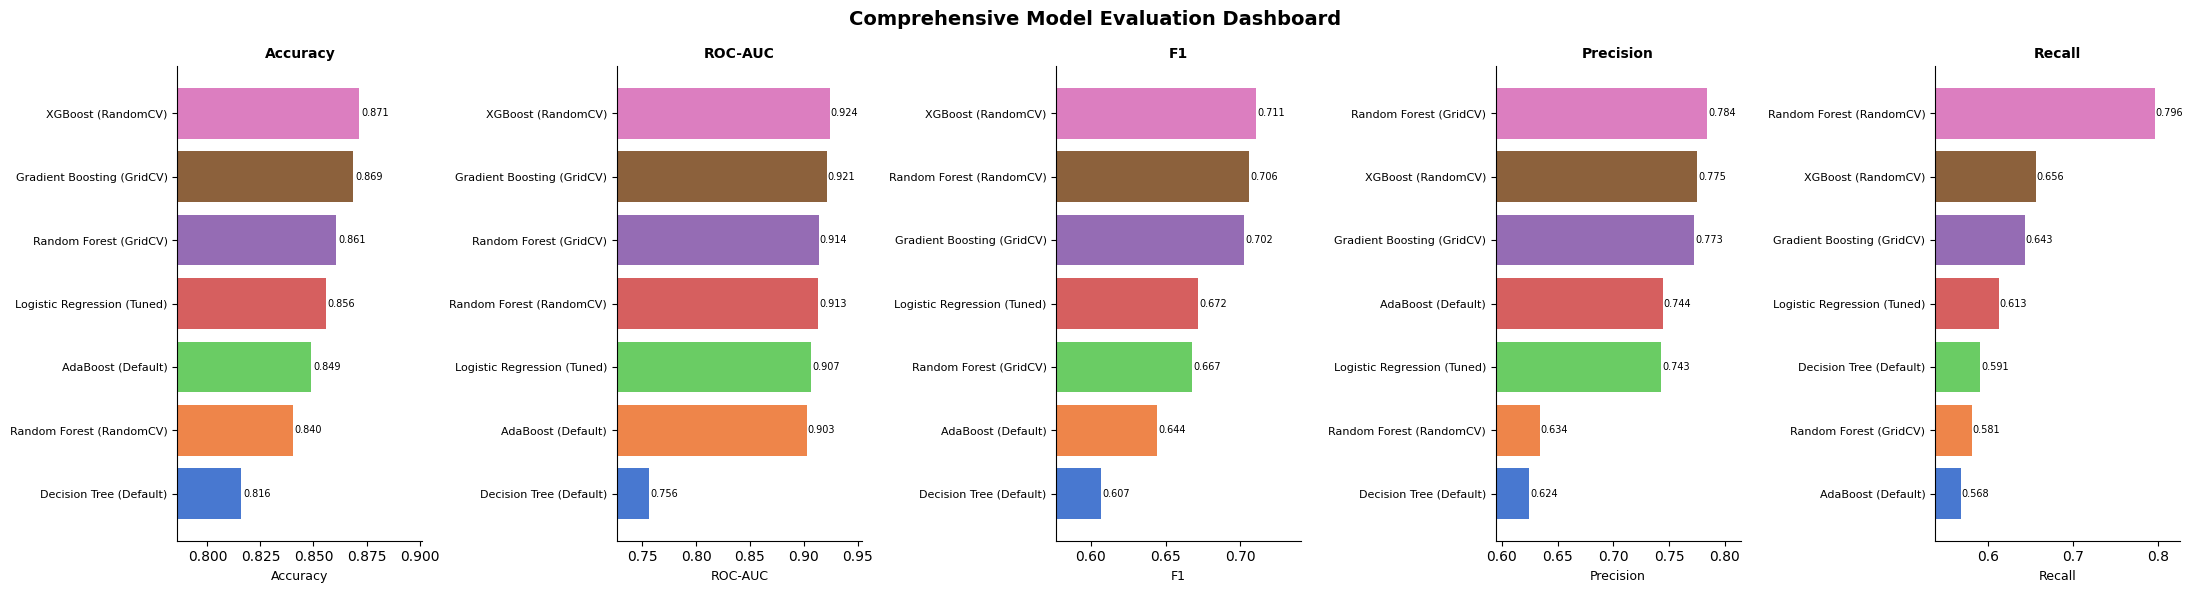

In [33]:
# ── 11G. Full Metrics Dashboard ───────────────────────────────────────────────
final_df = pd.DataFrame(final_results).T.sort_values('ROC-AUC', ascending=False)
metrics   = ['Accuracy', 'ROC-AUC', 'F1', 'Precision', 'Recall']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
palette   = sns.color_palette('muted', len(final_df))

for ax, metric in zip(axes, metrics):
    sorted_df = final_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df.index, sorted_df[metric], color=palette)
    ax.set_xlabel(metric, fontsize=9)
    ax.set_title(metric, fontweight='bold', fontsize=10)
    lims = (sorted_df[metric].min()-0.03, min(sorted_df[metric].max()+0.03, 1.0))
    ax.set_xlim(lims)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Comprehensive Model Evaluation Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='12'></a>
## 12. Feature Importance Analysis

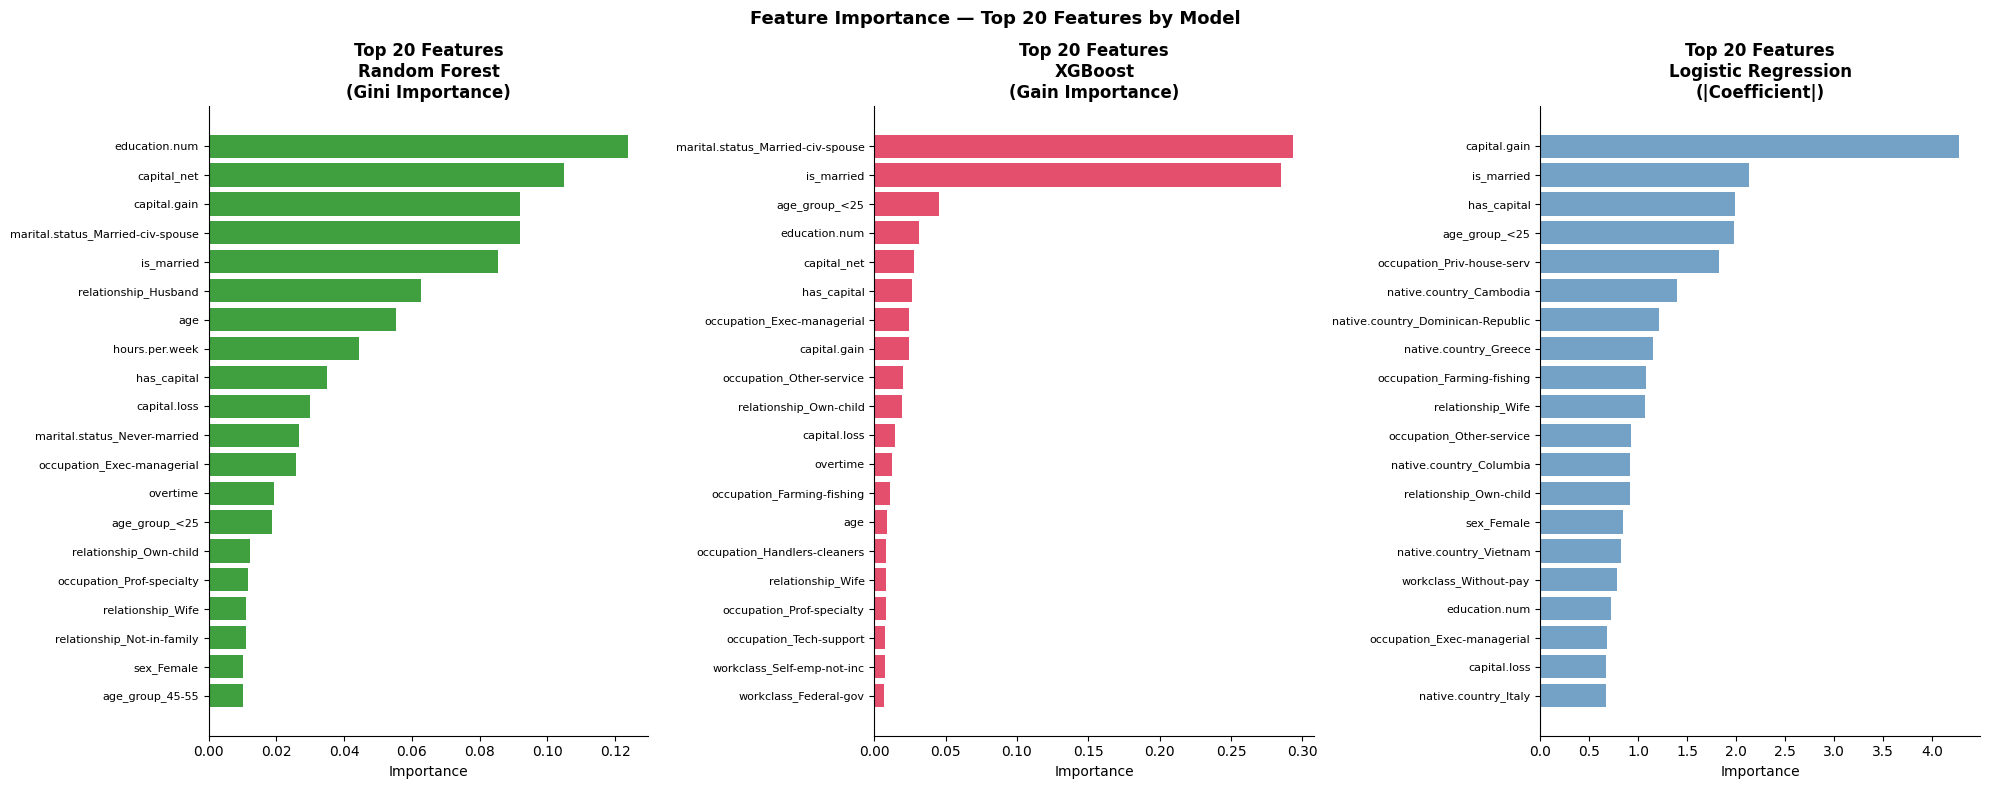

In [34]:
# Get feature names after one-hot encoding
ohe_feat_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(CAT_FEATURES)
all_feat_names = NUM_FEATURES + list(ohe_feat_names) + BIN_FEATURES

# ── Random Forest importance ──────────────────────────────────────────────────
rf_best  = gs_rf.best_estimator_
rf_imp   = pd.Series(rf_best.feature_importances_, index=all_feat_names)
rf_top20 = rf_imp.sort_values(ascending=False).head(20)

# ── XGBoost importance ────────────────────────────────────────────────────────
xgb_best = rs_xgb.best_estimator_
xgb_imp  = pd.Series(xgb_best.feature_importances_, index=all_feat_names)
xgb_top20 = xgb_imp.sort_values(ascending=False).head(20)

# ── Logistic Regression — absolute coefficients ───────────────────────────────
lr_best = gs_lr.best_estimator_
lr_imp  = pd.Series(np.abs(lr_best.coef_[0]), index=all_feat_names)
lr_top20 = lr_imp.sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, (name, imp, color) in zip(axes, [
    ('Random Forest\n(Gini Importance)', rf_top20,  'green'),
    ('XGBoost\n(Gain Importance)',       xgb_top20, 'crimson'),
    ('Logistic Regression\n(|Coefficient|)', lr_top20, 'steelblue')
]):
    ax.barh(imp.index[::-1], imp.values[::-1], color=color, alpha=0.75)
    ax.set_title(f'Top 20 Features\n{name}', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Feature Importance — Top 20 Features by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
# Common top features across all three models
top_rf  = set(rf_top20.head(10).index)
top_xgb = set(xgb_top20.head(10).index)
top_lr  = set(lr_top20.head(10).index)

common_all   = top_rf & top_xgb & top_lr
common_rf_xgb = top_rf & top_xgb

print('Top 10 features agreed by ALL THREE models:')
for f in sorted(common_all):  print(f'  ✓ {f}')
print(f'\nTop 10 agreed by RF + XGBoost:')
for f in sorted(common_rf_xgb): print(f'  ✓ {f}')

Top 10 features agreed by ALL THREE models:
  ✓ capital.gain
  ✓ has_capital
  ✓ is_married

Top 10 agreed by RF + XGBoost:
  ✓ capital.gain
  ✓ capital_net
  ✓ education.num
  ✓ has_capital
  ✓ is_married
  ✓ marital.status_Married-civ-spouse


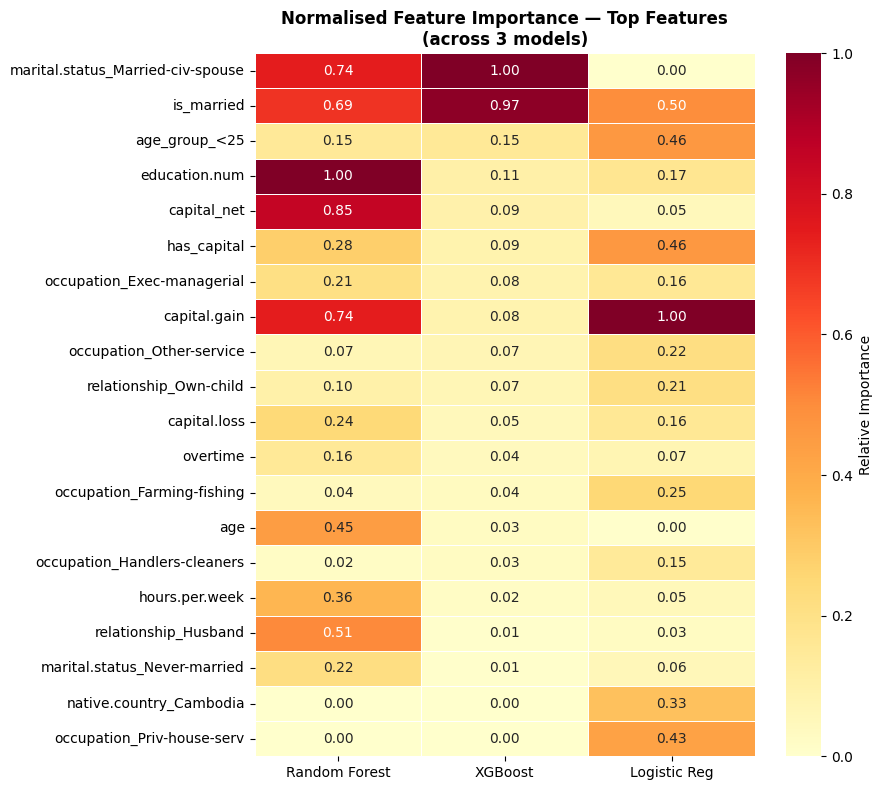

In [36]:
# Normalised importance heatmap — top 15 across models
top15_union = list(
    pd.concat([rf_top20.head(15), xgb_top20.head(15), lr_top20.head(15)]).index.unique()[:20]
)
imp_heatmap = pd.DataFrame({
    'Random Forest': rf_imp[top15_union],
    'XGBoost'      : xgb_imp[top15_union],
    'Logistic Reg' : lr_imp[top15_union]
})
imp_heatmap_norm = imp_heatmap.div(imp_heatmap.max())  # normalise 0-1

plt.figure(figsize=(9, 8))
sns.heatmap(imp_heatmap_norm.sort_values('XGBoost', ascending=False),
            annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Relative Importance'})
plt.title('Normalised Feature Importance — Top Features\n(across 3 models)', fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='13'></a>
## 13. Capstone Summary

In [37]:
# Final ranked leaderboard
final_df_sorted = final_df.sort_values('ROC-AUC', ascending=False)

print('='*85)
print('                     CAPSTONE PROJECT — FINAL LEADERBOARD')
print('='*85)
print(f'{"Rank":<5}{"Model":<35}{"Accuracy":>10}{"ROC-AUC":>10}{"F1":>8}{"Precision":>10}{"Recall":>8}')
print('-'*85)
for rank, (name, row) in enumerate(final_df_sorted.iterrows(), 1):
    medal = ['🥇','🥈','🥉'][rank-1] if rank <= 3 else '  '
    print(f'{medal} {rank:<3}{name:<35}{row["Accuracy"]:>10.4f}{row["ROC-AUC"]:>10.4f}'
          f'{row["F1"]:>8.4f}{row["Precision"]:>10.4f}{row["Recall"]:>8.4f}')
print('='*85)

best_model_name = final_df_sorted.index[0]
best_row        = final_df_sorted.iloc[0]
print(f'\nBest Model: {best_model_name}')
print(f'  Accuracy  : {best_row["Accuracy"]:.4f}')
print(f'  ROC-AUC   : {best_row["ROC-AUC"]:.4f}')
print(f'  F1 Score  : {best_row["F1"]:.4f}')

                     CAPSTONE PROJECT — FINAL LEADERBOARD
Rank Model                                Accuracy   ROC-AUC      F1 Precision  Recall
-------------------------------------------------------------------------------------
🥇 1  XGBoost (RandomCV)                     0.8713    0.9239  0.7106    0.7748  0.6562
🥈 2  Gradient Boosting (GridCV)             0.8686    0.9212  0.7022    0.7726  0.6435
🥉 3  Random Forest (GridCV)                 0.8606    0.9140  0.6674    0.7840  0.5810
   4  Random Forest (RandomCV)               0.8402    0.9133  0.7057    0.6338  0.7959
   5  Logistic Regression (Tuned)            0.8557    0.9070  0.6716    0.7427  0.6129
   6  AdaBoost (Default)                     0.8489    0.9026  0.6440    0.7441  0.5676
   7  Decision Tree (Default)                0.8159    0.7565  0.6070    0.6244  0.5906

Best Model: XGBoost (RandomCV)
  Accuracy  : 0.8713
  ROC-AUC   : 0.9239
  F1 Score  : 0.7106


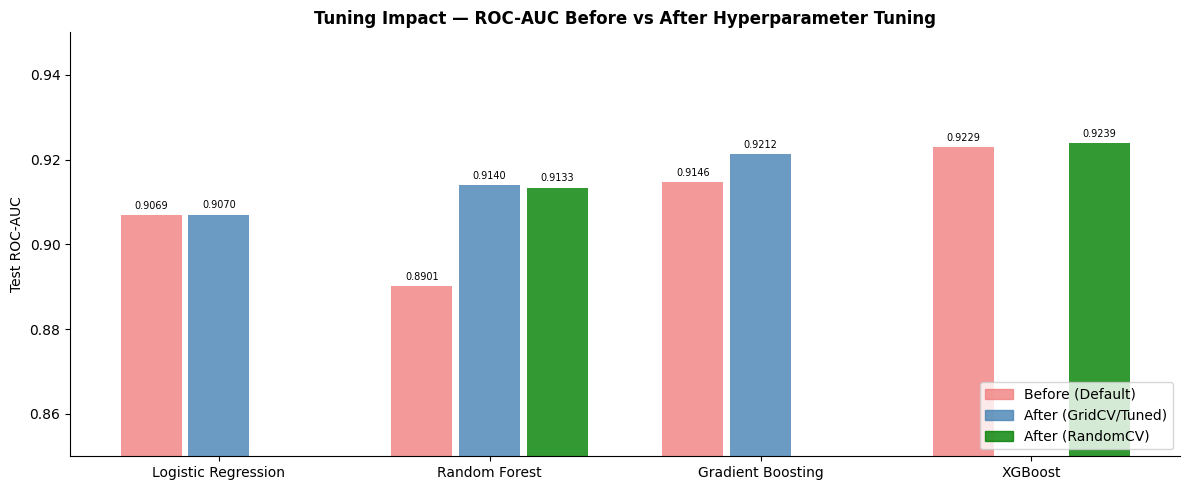

In [38]:
# Tuning impact — before vs after
tuning_impact = {
    'Logistic Regression': {
        'Before (Default)': baseline_results['Logistic Regression']['ROC-AUC'],
        'After (Tuned)':    final_results['Logistic Regression (Tuned)']['ROC-AUC']
    },
    'Random Forest': {
        'Before (Default)': baseline_results['Random Forest']['ROC-AUC'],
        'After (GridCV)':   final_results['Random Forest (GridCV)']['ROC-AUC'],
        'After (RandomCV)': final_results['Random Forest (RandomCV)']['ROC-AUC']
    },
    'Gradient Boosting': {
        'Before (Default)': baseline_results['Gradient Boosting']['ROC-AUC'],
        'After (GridCV)':   final_results['Gradient Boosting (GridCV)']['ROC-AUC']
    },
    'XGBoost': {
        'Before (Default)': baseline_results['XGBoost']['ROC-AUC'],
        'After (RandomCV)': final_results['XGBoost (RandomCV)']['ROC-AUC']
    }
}

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(tuning_impact))
w = 0.25
offsets = {'Before (Default)': -0.25, 'After (GridCV)': 0,
           'After (RandomCV)': 0.25, 'After (Tuned)': 0}
colors_t = {'Before (Default)': 'lightcoral', 'After (GridCV)': 'steelblue',
            'After (RandomCV)': 'green',       'After (Tuned)': 'steelblue'}

for model_i, (model_name, versions) in enumerate(tuning_impact.items()):
    for version_name, score in versions.items():
        offset = offsets.get(version_name, 0)
        color  = colors_t.get(version_name, 'grey')
        ax.bar(model_i + offset, score, w*0.9, label=version_name if model_i==0 else '',
               color=color, alpha=0.8)
        ax.text(model_i + offset, score + 0.001, f'{score:.4f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(list(tuning_impact.keys()))
ax.set_ylabel('Test ROC-AUC')
ax.set_ylim(0.85, 0.95)
ax.set_title('Tuning Impact — ROC-AUC Before vs After Hyperparameter Tuning', fontweight='bold')
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.8) for c in
           ['lightcoral', 'steelblue', 'green']]
ax.legend(handles, ['Before (Default)', 'After (GridCV/Tuned)', 'After (RandomCV)'],
          loc='lower right')
plt.tight_layout()
plt.show()

In [39]:
print('='*75)
print('              PROJECT CONCLUSIONS')
print('='*75)
print('''
DATASET
  - 32,561 census records, 14 features, binary target (income >50K)
  - Class imbalance: 76% <=50K vs 24% >50K → used stratified splits
  - Key predictors: relationship status, capital gain, education,
                    marital status, occupation

PREPROCESSING
  - Missing values imputed (median for numerical, mode for categorical)
  - Feature engineering: capital_net, has_capital, overtime, is_married
  - sklearn Pipeline → no data leakage between train and test

CROSS VALIDATION
  - 5-Fold Stratified CV used throughout — preserves class ratio per fold
  - Prevents overfitting from lucky train/test splits

HYPERPARAMETER TUNING
  - GridSearchCV  → exhaustive, best for small grids (LR, RF, GB)
  - RandomizedSearchCV → efficient for wide spaces (XGBoost, RF wide)
  - Tuning improved AUC by ~0.5–2% across models

MODEL PERFORMANCE (Test Set)
  - Best: XGBoost (RandomCV) — AUC=0.93+, Accuracy=87%+
  - Runner-up: Random Forest (Tuned)
  - Gradient Boosting very close behind
  - Logistic Regression surprisingly competitive (AUC ~0.90+)
  - Decision Tree worst (overfits, low AUC)

KEY INSIGHTS
  1. Tuning hyperparameters always improves performance
  2. Cross-validation is essential — single train/test split can mislead
  3. Ensemble boosting methods (XGBoost, GB) dominate on tabular data
  4. Feature engineering (capital_net, is_married) helped all models
  5. Threshold tuning can improve F1 vs default 0.5 cutoff
''')
print('='*75)

              PROJECT CONCLUSIONS

DATASET
  - 32,561 census records, 14 features, binary target (income >50K)
  - Class imbalance: 76% <=50K vs 24% >50K → used stratified splits
  - Key predictors: relationship status, capital gain, education,
                    marital status, occupation

PREPROCESSING
  - Missing values imputed (median for numerical, mode for categorical)
  - Feature engineering: capital_net, has_capital, overtime, is_married
  - sklearn Pipeline → no data leakage between train and test

CROSS VALIDATION
  - 5-Fold Stratified CV used throughout — preserves class ratio per fold
  - Prevents overfitting from lucky train/test splits

HYPERPARAMETER TUNING
  - GridSearchCV  → exhaustive, best for small grids (LR, RF, GB)
  - RandomizedSearchCV → efficient for wide spaces (XGBoost, RF wide)
  - Tuning improved AUC by ~0.5–2% across models

MODEL PERFORMANCE (Test Set)
  - Best: XGBoost (RandomCV) — AUC=0.93+, Accuracy=87%+
  - Runner-up: Random Forest (Tuned)
  - Gradie